# COMEÇO KNN

In [ ]:
# IMPORTS
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier, export_text

SHEET_ID = "1g1aQ61vijh6uHJuc8sijeBEMsoIQ2a5yLwUK04Wptlg"
GID = "282951434"
url_csv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

df = pd.read_csv(url_csv)

df.columns = [
    "data_hora",
    "gripou",
    "tomou_vacina",
    "ambientes_cheios",
    "viajou",
    "alergia",
    "horas_sono",
    "atividade_fisica",
    "alimentacao_balanceada",
    "lavou_maos",
    "nivel_estresse"
]

print("Colunas lidas (renomeadas):", list(df.columns))
display(df.head())

Colunas lidas (renomeadas): ['data_hora', 'gripou', 'tomou_vacina', 'ambientes_cheios', 'viajou', 'alergia', 'horas_sono', 'atividade_fisica', 'alimentacao_balanceada', 'lavou_maos', 'nivel_estresse']


,data_hora,gripou,tomou_vacina,ambientes_cheios,viajou,alergia,horas_sono,atividade_fisica,alimentacao_balanceada,lavou_maos,nivel_estresse
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


In [ ]:
# O que vamos prever (TARGET) e quais dados usar (FEATURES)
TARGET = "gripou"
FEATURES = [
    "tomou_vacina", "ambientes_cheios", "viajou", "alergia",
    "horas_sono", "atividade_fisica", "alimentacao_balanceada",
    "lavou_maos", "nivel_estresse"
]

df = df.dropna(subset=FEATURES + [TARGET]).copy()

df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()

for col in FEATURES:
    df[col] = df[col].astype(str).str.strip()
    le_feat = LabelEncoder()
    df[col] = le_feat.fit_transform(df[col])

le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("\nClasses do Target:", list(le.classes_))
print("Total linhas válidas:", len(df))


Classes do Target: ['não', 'sim']
Total linhas válidas: 185


In [ ]:
# Divisão em Treino e Teste
RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
limite_teste = int(len(df) * 0.20) # Split: 20% teste + 80% treino

test_df  = df_shuffled.iloc[:limite_teste].copy()
train_df = df_shuffled.iloc[limite_teste:len(df)].copy()

X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])
X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])
print("\nTreino:", len(train_df), "| Teste:", len(test_df))

def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts(dropna=False)
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"qtd": vc, "%": pct})
    print(f"\n=== {titulo} (n={len(frame)}) ===")
    display(out)

dist_classes(df, TARGET, "Dataset completo")
dist_classes(train_df, TARGET, "Treino")
dist_classes(test_df, TARGET, "Teste")


Treino: 148 | Teste: 37

=== Dataset completo (n=185) ===


,qtd,%
gripou,,
sim,108,58.4
não,77,41.6



=== Treino (n=148) ===


,qtd,%
gripou,,
sim,87,58.8
não,61,41.2



=== Teste (n=37) ===


,qtd,%
gripou,,
sim,21,56.8
não,16,43.2


In [ ]:
# Treinamento do Modelo KNN
K = 5
WEIGHTS = "distance"

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=WEIGHTS))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n=== Resultados do KNN ===")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred))

test_df["classe_prevista_knn"] = le.inverse_transform(y_pred)
display(test_df[FEATURES + [TARGET, "classe_prevista_knn"]].head())


=== Resultados do KNN ===
Acurácia: 0.43243243243243246

Relatório de Classificação:
              precision    recall  f1-score   support

         não       0.31      0.25      0.28        16
         sim       0.50      0.57      0.53        21

    accuracy                           0.43        37
   macro avg       0.40      0.41      0.40        37
weighted avg       0.42      0.43      0.42        37

Matriz de confusão (real x previsto):
[[ 4 12]
 [ 9 12]]


,tomou_vacina,ambientes_cheios,viajou,alergia,horas_sono,atividade_fisica,alimentacao_balanceada,lavou_maos,nivel_estresse,gripou,classe_prevista_knn
0,0,1,1,2,1,1,0,3,3,não,sim
1,0,1,2,0,1,0,1,1,4,sim,sim
2,0,1,1,2,2,1,2,1,2,sim,sim
3,1,1,1,3,2,1,1,3,2,não,não
4,1,1,1,2,2,1,2,0,2,não,sim



=== Resultados da Árvore de Decisão ===
Acurácia: 0.5675675675675675

Relatório de Classificação:
              precision    recall  f1-score   support

         não       0.50      0.38      0.43        16
         sim       0.60      0.71      0.65        21

    accuracy                           0.57        37
   macro avg       0.55      0.54      0.54        37
weighted avg       0.56      0.57      0.56        37

Matriz de confusão (real x previsto):
[[ 6 10]
 [ 6 15]]


,tomou_vacina,ambientes_cheios,viajou,alergia,horas_sono,atividade_fisica,alimentacao_balanceada,lavou_maos,nivel_estresse,gripou,classe_prevista_arvore
0,0,1,1,2,1,1,0,3,3,não,não
1,0,1,2,0,1,0,1,1,4,sim,sim
2,0,1,1,2,2,1,2,1,2,sim,sim
3,1,1,1,3,2,1,1,3,2,não,não
4,1,1,1,2,2,1,2,0,2,não,sim


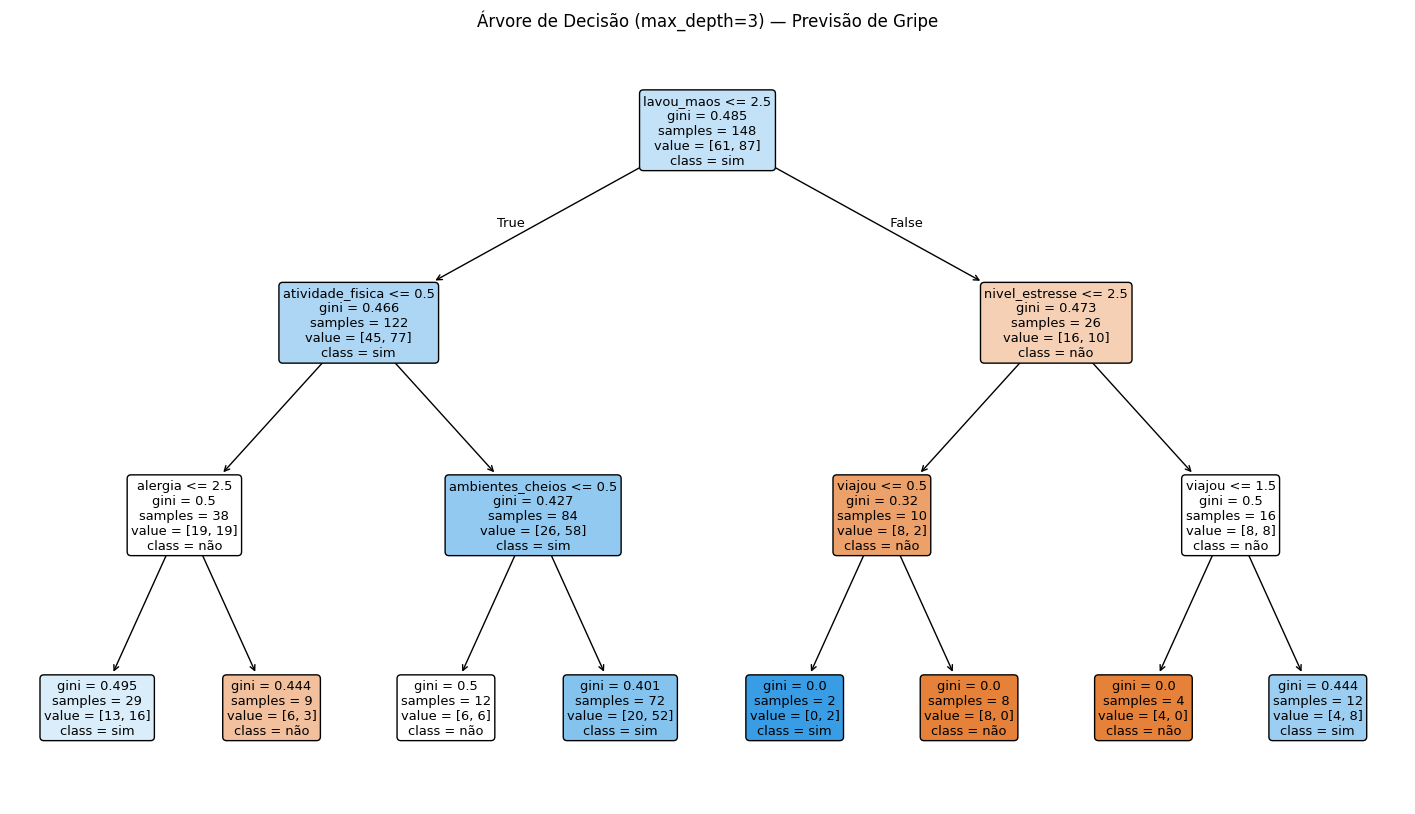

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n=== Resultados da Árvore de Decisão ===")
print("Acurácia:", accuracy_score(y_test, y_pred_tree))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_tree, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_tree))

test_df["classe_prevista_arvore"] = le.inverse_transform(y_pred_tree)
display(test_df[FEATURES + [TARGET, "classe_prevista_arvore"]].head())

plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Árvore de Decisão (max_depth=3) — Previsão de Gripe")
plt.show()

# FIM MODELO KNN

# MODELO Naive Bayes

In [ ]:


nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("\n=== Resultados do Naive Bayes ===")
print("Acurácia:", accuracy_score(y_test, y_pred_nb))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))
print("Matriz de confusão (real x previsto):")
print(confusion_matrix(y_test, y_pred_nb))

test_df["classe_prevista_naive"] = le.inverse_transform(y_pred_nb)
display(test_df[FEATURES + [TARGET, "classe_prevista_naive"]].head())

probabilidades = nb_model.predict_proba(X_test)

print("\n=== Probabilidades Normalizadas (Primeiros 5 casos) ===")
df_probs = pd.DataFrame(probabilidades, columns=[f"Chance de {c}" for c in le.classes_])
display(df_probs.head().style.format("{:.2%}"))


=== Resultados do Naive Bayes ===
Acurácia: 0.5135135135135135

Relatório de Classificação:
              precision    recall  f1-score   support

         não       0.43      0.38      0.40        16
         sim       0.57      0.62      0.59        21

    accuracy                           0.51        37
   macro avg       0.50      0.50      0.50        37
weighted avg       0.51      0.51      0.51        37

Matriz de confusão (real x previsto):
[[ 6 10]
 [ 8 13]]


,tomou_vacina,ambientes_cheios,viajou,alergia,horas_sono,atividade_fisica,alimentacao_balanceada,lavou_maos,nivel_estresse,gripou,classe_prevista_naive
0,0,1,1,2,1,1,0,3,3,não,sim
1,0,1,2,0,1,0,1,1,4,sim,sim
2,0,1,1,2,2,1,2,1,2,sim,sim
3,1,1,1,3,2,1,1,3,2,não,não
4,1,1,1,2,2,1,2,0,2,não,sim



=== Probabilidades Normalizadas (Primeiros 5 casos) ===


,Chance de não,Chance de sim
0,49.02%,50.98%
1,16.58%,83.42%
2,39.98%,60.02%
3,63.92%,36.08%
4,39.46%,60.54%


# FIM MODELO Naive Bayes

# Modelo Árvore de Decisão: Algoritmo ID3 (Entropia)



=== Resultados da Árvore ID3 (Entropia) ===
Acurácia: 0.5945945945945946

Relatório de Classificação:
              precision    recall  f1-score   support

         não       0.53      0.50      0.52        16
         sim       0.64      0.67      0.65        21

    accuracy                           0.59        37
   macro avg       0.58      0.58      0.58        37
weighted avg       0.59      0.59      0.59        37



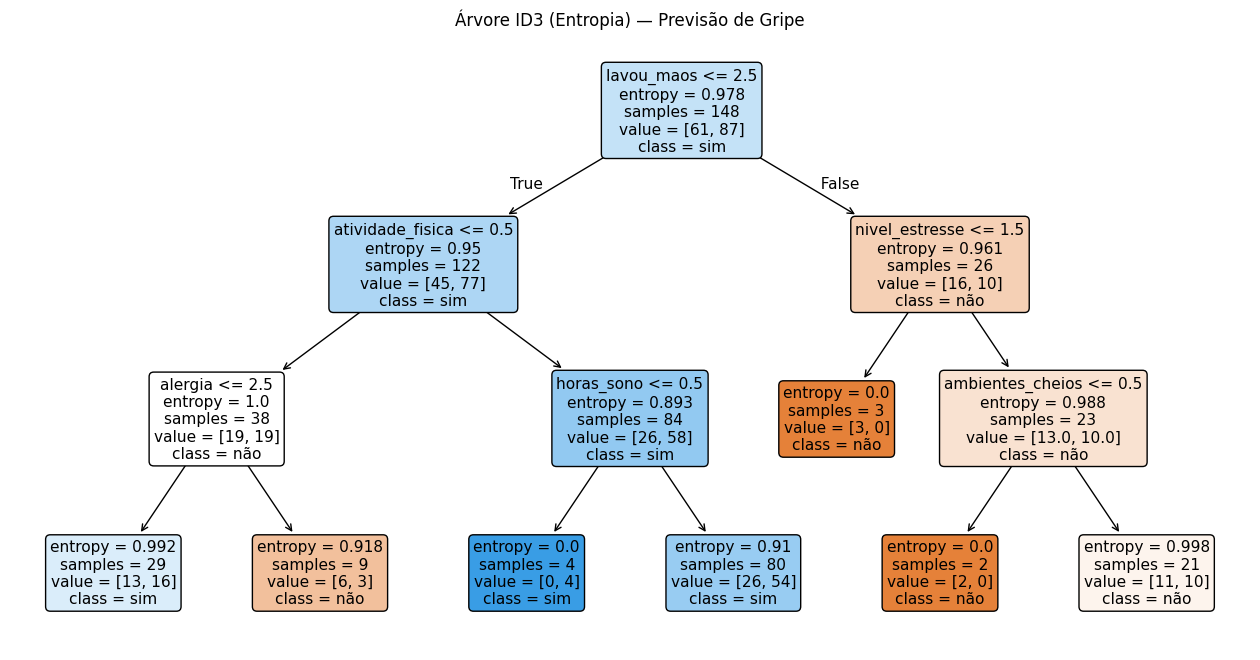

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

id3_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=RANDOM_STATE
)

id3_model.fit(X_train, y_train)
y_pred_id3 = id3_model.predict(X_test)

print("\n=== Resultados da Árvore ID3 (Entropia) ===")
print("Acurácia:", accuracy_score(y_test, y_pred_id3))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_id3, target_names=le.classes_))

plt.figure(figsize=(16, 8))
plot_tree(
    id3_model,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True
)
plt.title("Árvore ID3 (Entropia) — Previsão de Gripe")
plt.show()

# Modelo Árvore de Decisão: Algoritmo CART (Gini)



=== Resultados da Árvore CART (Gini) ===
Acurácia: 0.5675675675675675

Relatório de Classificação:
              precision    recall  f1-score   support

         não       0.50      0.38      0.43        16
         sim       0.60      0.71      0.65        21

    accuracy                           0.57        37
   macro avg       0.55      0.54      0.54        37
weighted avg       0.56      0.57      0.56        37



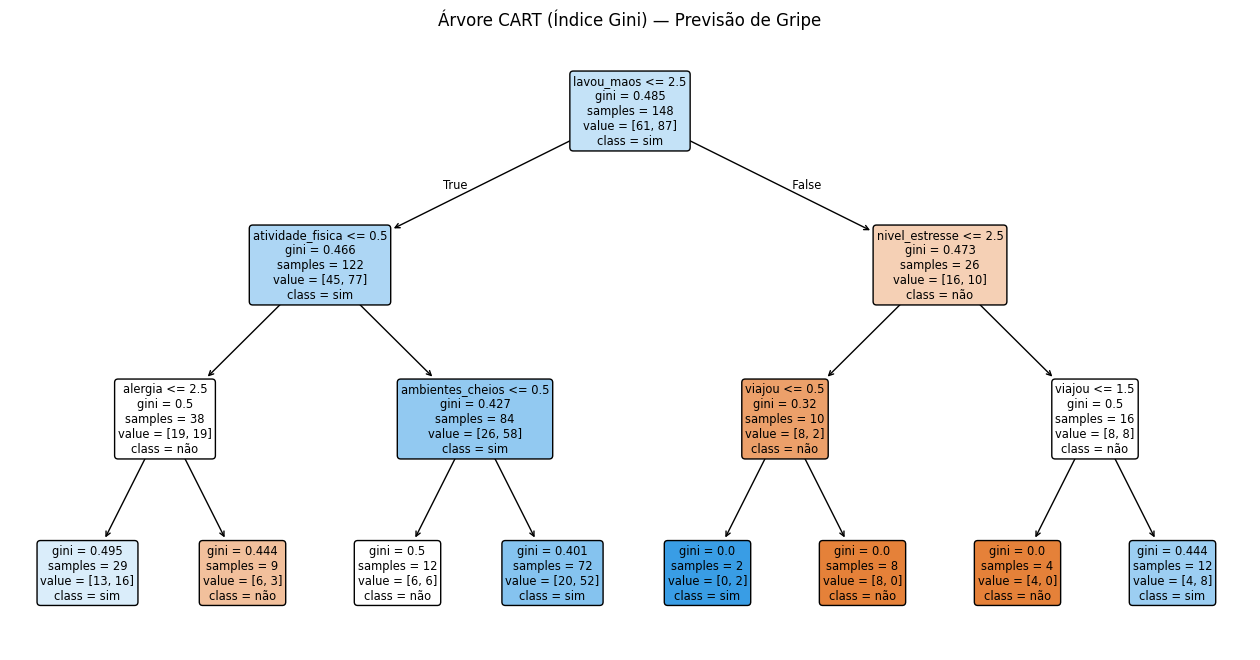

In [ ]:

cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=RANDOM_STATE
)

cart_model.fit(X_train, y_train)
y_pred_cart = cart_model.predict(X_test)

print("\n=== Resultados da Árvore CART (Gini) ===")
print("Acurácia:", accuracy_score(y_test, y_pred_cart))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_cart, target_names=le.classes_))

plt.figure(figsize=(16, 8))
plot_tree(
    cart_model,
    feature_names=FEATURES,
    class_names=list(le.classes_),
    filled=True,
    rounded=True
)
plt.title("Árvore CART (Índice Gini) — Previsão de Gripe")
plt.show()

# Modelo Árvore de Regressão (SDR)


In [ ]:

TARGET_REG = "nivel_estresse"

df["gripou_num"] = df["gripou"].apply(lambda x: 1 if x == 'sim' else 0)

FEATURES_REG = [
    "gripou_num", "tomou_vacina", "ambientes_cheios", "viajou", "alergia",
    "horas_sono", "atividade_fisica", "alimentacao_balanceada", "lavou_maos"
]

X_reg = df[FEATURES_REG].values
y_reg = df[TARGET_REG].astype(float).values #

X_train_reg = X_reg[limite_teste:]
y_train_reg = y_reg[limite_teste:]
X_test_reg  = X_reg[:limite_teste]
y_test_reg  = y_reg[:limite_teste]

reg_tree = DecisionTreeRegressor(
    max_depth=3,
    random_state=RANDOM_STATE
)

reg_tree.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_tree.predict(X_test_reg)

print("\n=== Resultados da Árvore de Regressão (Previsão de Estresse) ===")

mae = round(mean_absolute_error(y_test_reg, y_pred_reg), 2)
r2 = round(r2_score(y_test_reg, y_pred_reg), 2)

print(f"Erro Médio Absoluto (MAE): {mae} pontos de estresse")
print(f"Métrica R² (Explicação): {r2}")

df_reg_resultado = pd.DataFrame({
    "Estresse Real": y_test_reg,
    "Estresse Previsto (Média da Folha)": y_pred_reg.round(1)
})
display(df_reg_resultado.head(10))


=== Resultados da Árvore de Regressão (Previsão de Estresse) ===
Erro Médio Absoluto (MAE): 0.74 pontos de estresse
Métrica R² (Explicação): -0.28


,Estresse Real,Estresse Previsto (Média da Folha)
0,4.0,3.3
1,2.0,2.9
2,2.0,2.8
3,1.0,3.6
4,3.0,3.3
5,3.0,2.2
6,1.0,2.3
7,3.0,2.3
8,3.0,2.9
9,3.0,3.3


# FIM MODELO DE ARVORES

# Modelo de Regras: Algoritmo 1R (One Rule)


In [ ]:

one_rule_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=RANDOM_STATE
)

one_rule_model.fit(X_train, y_train)
y_pred_1r = one_rule_model.predict(X_test)

print("\n=== Resultados do Modelo 1R (One Rule) ===")
print("Acurácia:", accuracy_score(y_test, y_pred_1r))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_1r, target_names=le.classes_))

print("\n=== A Regra Escolhida pelo 1R ===")
regra_1r = export_text(one_rule_model, feature_names=FEATURES)
print(regra_1r)


=== Resultados do Modelo 1R (One Rule) ===
Acurácia: 0.5405405405405406

Relatório de Classificação:
              precision    recall  f1-score   support

         não       0.46      0.38      0.41        16
         sim       0.58      0.67      0.62        21

    accuracy                           0.54        37
   macro avg       0.52      0.52      0.52        37
weighted avg       0.53      0.54      0.53        37


=== A Regra Escolhida pelo 1R ===
|--- lavou_maos <= 2.50
|   |--- class: 1
|--- lavou_maos >  2.50
|   |--- class: 0



# Extração de Regras (Indução a partir de Árvores)


In [ ]:

print("=== Conjunto de Regras Extraídas do Modelo ===")
regras_texto = export_text(tree, feature_names=FEATURES)
print(regras_texto)

print("\n---------------------------------------------------------")
print("DICA DE LEITURA DAS REGRAS NO PYTHON:")
print("Como convertemos as categorias de texto em números lá na Seção 2:")
print("-> Valores <= 0.50 normalmente indicam a classe 'Não' ou 'Nuca'.")
print("-> Valores > 0.50 indicam a classe 'Sim' ou categorias maiores.")
print("A 'class' no final da regra indica o Target (Ex: class: 0 é Não Gripou, class: 1 é Gripou).")
print("---------------------------------------------------------")

=== Conjunto de Regras Extraídas do Modelo ===
|--- lavou_maos <= 2.50
|   |--- atividade_fisica <= 0.50
|   |   |--- alergia <= 2.50
|   |   |   |--- class: 1
|   |   |--- alergia >  2.50
|   |   |   |--- class: 0
|   |--- atividade_fisica >  0.50
|   |   |--- ambientes_cheios <= 0.50
|   |   |   |--- class: 0
|   |   |--- ambientes_cheios >  0.50
|   |   |   |--- class: 1
|--- lavou_maos >  2.50
|   |--- nivel_estresse <= 2.50
|   |   |--- viajou <= 0.50
|   |   |   |--- class: 1
|   |   |--- viajou >  0.50
|   |   |   |--- class: 0
|   |--- nivel_estresse >  2.50
|   |   |--- viajou <= 1.50
|   |   |   |--- class: 0
|   |   |--- viajou >  1.50
|   |   |   |--- class: 1


---------------------------------------------------------
DICA DE LEITURA DAS REGRAS NO PYTHON:
Como convertemos as categorias de texto em números lá na Seção 2:
-> Valores <= 0.50 normalmente indicam a classe 'Não' ou 'Nuca'.
-> Valores > 0.50 indicam a classe 'Sim' ou categorias maiores.
A 'class' no final da regr

# FIM REGRAS